In [38]:
!!pip install -q https://github.com/keras-team/keras-hub.git
!!pip install -q --upgrade keras  # Upgrade to Keras 3

[]

In [39]:
import os
import json
import math
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras import losses
from keras import ops
from keras import optimizers
from keras.optimizers import schedules
from keras import metrics
from keras.applications.imagenet_utils import decode_predictions
import keras_hub

# Import tensorflow for `tf.data` and its preprocessing functions
import tensorflow as tf
import tensorflow_datasets as tfds

In [40]:
from tensorflow import keras
from keras.layers import Dropout, Dense, GlobalAveragePooling1D, Flatten
import keras_hub

from keras import layers
from keras.layers import Lambda

# import tensorflow as tf
# from tensorflow import keras
# import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# initialize the seeds of different random number generators so that the
# results will be the same every time the notebook is run
keras.utils.set_random_seed(42)

In [42]:
!curl -L -o handbags-shoes.zip https://www.dropbox.com/s/w07liww46kgxo1m/handbags-shoes.zip
!unzip -o -qq handbags-shoes.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   126  100   126    0     0    844      0 --:--:-- --:--:-- --:--:--   845
100    17  100    17    0     0     29      0 --:--:-- --:--:-- --:--:--     0
100   491    0   491    0     0    424      0 --:--:--  0:00:01 --:--:--   424
100 17.1M  100 17.1M    0     0  8178k      0  0:00:02  0:00:02 --:--:-- 35.7M


In [43]:
import os, shutil, pathlib
base_dir = pathlib.Path("./handbags-shoes")

In [45]:
import os
import shutil

for category in ('handbags', 'shoes'):
    fnames = os.listdir(base_dir / category)
    
    # 1. Train Split
    dir = base_dir / 'train' / category
    os.makedirs(dir, exist_ok=True)  # Added exist_ok=True here
    for fname in fnames[:50]:
        shutil.copyfile(src=base_dir/category/fname, dst=dir/fname)
        
    # 2. Validation Split
    dir = base_dir / 'validation' / category
    os.makedirs(dir, exist_ok=True)  # Added exist_ok=True here
    for fname in fnames[50:75]:
        shutil.copyfile(src=base_dir/category/fname, dst=dir/fname)
        
    # 3. Test Split
    dir = base_dir / 'test' / category
    os.makedirs(dir, exist_ok=True)  # Added exist_ok=True here
    for fname in fnames[75:]:
        shutil.copyfile(src=base_dir/category/fname, dst=dir/fname)

In [46]:
train_dataset = keras.utils.image_dataset_from_directory(base_dir / 'train', image_size=(224, 224), batch_size=32)

validation_dataset = keras.utils.image_dataset_from_directory(base_dir / 'validation', image_size=(224, 224), batch_size=32)

test_dataset = keras.utils.image_dataset_from_directory(base_dir / 'test', image_size=(224, 224), batch_size=32)

Found 98 files belonging to 2 classes.
Found 48 files belonging to 2 classes.
Found 39 files belonging to 2 classes.


In [47]:
for images, _ in train_dataset.take(1):
  print(images[0].shape)

(224, 224, 3)


In [50]:
# Number of classes
num_classes = 2  # Adjust to the number of classes in your dataset

# Preprocessing function for both images and labels
def preprocess_data(image, label):
    # Cast label from float32 to int32 so tf.one_hot can use it as an index
    label = tf.cast(label, tf.int32)
    label = tf.one_hot(label, num_classes)  # Convert labels to one-hot
    return image, label


train_dataset = train_dataset.map(preprocess_data)
validation_dataset = validation_dataset.map(preprocess_data)
test_dataset = test_dataset.map(preprocess_data)

for images, labels in train_dataset.take(1):
    print("Image shape:", images.shape)  # Should be (32, 224, 224, 3)
    print("Label shape:", labels.shape)  # Should be (32, num_classes)

Image shape: (32, 224, 224, 3)
Label shape: (32, 2, 2)


2026-07-12 14:54:13.022550: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


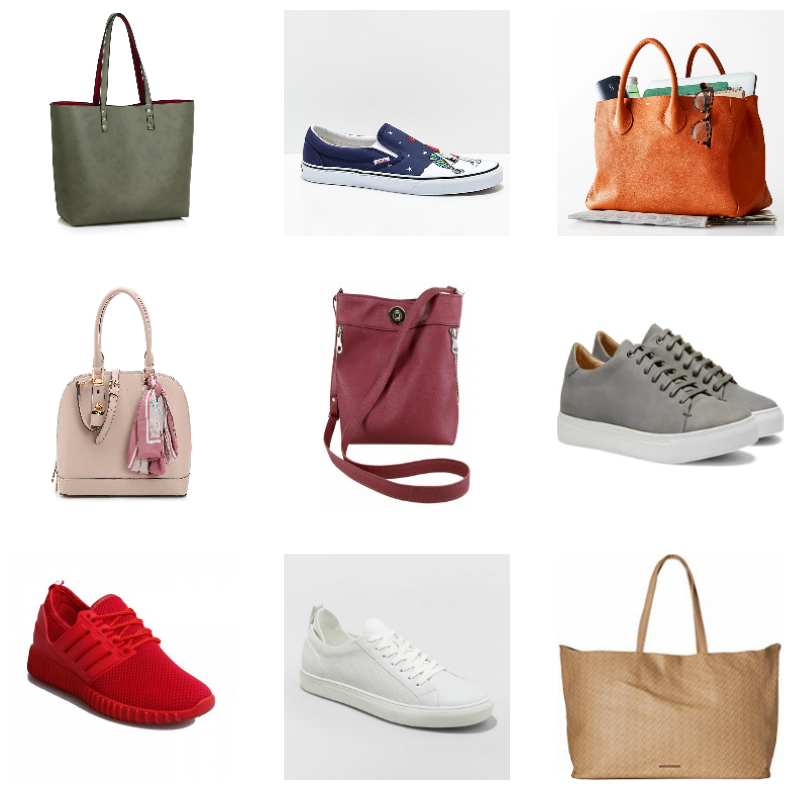

In [51]:
plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")

In [52]:
patch_size = 16
image_size = 224

In [53]:
def get_patches(images, patch_size=16):
    input_shape = tf.shape(images)  # Changed keras.ops.shape to tf.shape
    batch_size = input_shape[0]
    height = input_shape[1]
    width = input_shape[2]
    channels = input_shape[3]
    num_patches_h = height // patch_size
    num_patches_w = width // patch_size
    # key utility that breaks up an image into patches.
    # Returns batch_size x patch_index_i x patch_index_j x vectorized_patch_dimension
    patches = tf.image.extract_patches(images=images, # Added images= for clarity
                                      sizes=[1, patch_size, patch_size, 1], strides=[1, patch_size, patch_size, 1], rates=[1, 1, 1, 1], padding='VALID')
    # Using tf.reshape for consistency with other TensorFlow operations
    # Cast patches to float32 to ensure compatibility
    patches = tf.reshape(tf.cast(patches, dtype=tf.float32), # Cast patches to float32
        (batch_size, num_patches_h * num_patches_w, patch_size * patch_size * channels,),)
    return patches

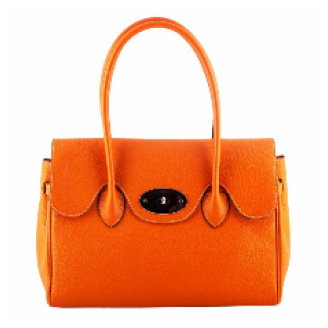

In [54]:
for images, _ in train_dataset.take(1):
    plt.figure(figsize=(4, 4))
    resized_image = keras.ops.image.resize(keras.ops.convert_to_tensor([images[0]]), size=(image_size, image_size))
    no_channels = keras.ops.shape(resized_image)[-1]

    plt.imshow(images[0].numpy().astype("uint8"))
    plt.axis("off")

Image size: 224 X 224
Patch size: 16 X 16
Patches per image: 196
Elements per patch: 768


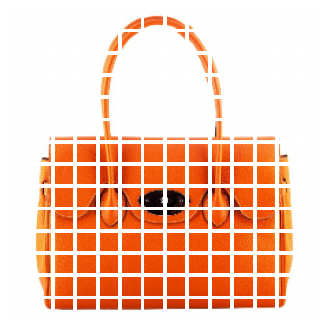

In [55]:
patches = get_patches(resized_image)
print(f"Image size: {image_size} X {image_size}")
print(f"Patch size: {patch_size} X {patch_size}")
print(f"Patches per image: {patches.shape[1]}")
print(f"Elements per patch: {patches.shape[-1]}")

n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(4, 4))
for i, patch in enumerate(patches[0]):
    ax = plt.subplot(n, n, i + 1)
    patch_img = keras.ops.reshape(patch.numpy(), (16, 16, no_channels))
    plt.imshow(keras.ops.convert_to_numpy(patch_img).astype("uint8"))
    plt.axis("off")

In [56]:
#Recall num_patches is akin to the length of our context window
num_patches = (image_size // patch_size) ** 2

#Transformer dimensions
projection_dim = 64
num_heads = 8
transformer_units = [
    projection_dim * 2,
    projection_dim,
]  #no. units in the feedforward portion of the tranfomers
num_transformer_layers = 2

#Classification head dimensions
mlp_head_units = [
    512,
    256,
]

num_classes = 2
input_shape = (image_size, image_size, 3)

In [57]:
inputs = keras.Input(shape=input_shape)

# Define data augmentation pipeline
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomTranslation(0.1, 0.1),
])
x = data_augmentation(inputs)

# Create patches.
patches = Lambda(get_patches, output_shape=(num_patches, patch_size * patch_size * 3))(x)

# Encode patches by projecting and then adding a position embedding
projection = layers.Dense(units=projection_dim)
position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )
encoded_patches = projection(patches) + position_embedding(keras.ops.expand_dims(keras.ops.arange(start=0, stop=num_patches, step=1), axis=0))

# Create multiple layers of the Transformer block.
for _ in range(num_transformer_layers):
    # Layer normalization 1.
    x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    # Create a multi-head attention layer.
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=projection_dim, dropout=0.1
    )(x1, x1)
    # Skip connection 1.
    x2 = layers.Add()([attention_output, encoded_patches])
    # Layer normalization 2.
    x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
    # MLP.
    for units in transformer_units:
        x3 = layers.Dense(units, activation=keras.activations.gelu)(x3)
        x3 = layers.Dropout(0.5)(x3)
    # Skip connection 2.
    encoded_patches = layers.Add()([x3, x2])


# Create a [batch_size, projection_dim] tensor.
representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
representation = layers.Flatten()(representation)
representation = layers.Dropout(0.5)(representation)

# Add MLP.
for units in mlp_head_units:
    representation = layers.Dense(units, activation=keras.activations.gelu)(representation)
    representation = layers.Dropout(0.5)(representation)

# Classify outputs.
logits = layers.Dense(num_classes)(representation)

# Create the Keras model.
model = keras.Model(inputs=inputs, outputs=logits)


In [58]:
optimizer = keras.optimizers.AdamW(
    learning_rate=0.001
)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.CategoricalAccuracy(name="accuracy"),
    ],
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 196, 768)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 196, 64)   │     49,216 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 64)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │    132,672 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 196, 128)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196, 64)   │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 196, 64)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 196, 64)   │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │    132,672 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 6,903,234 (26.33 MB)

 Trainable params: 6,903,234 (26.33 MB)

 Non-trainable params: 0 (0.00 B)

In [72]:
import numpy as np
import tensorflow as tf

# 1. Extract the raw numpy data from the datasets and fix the label shapes directly
print("Extracting training data...")
x_train = np.concatenate([x.numpy() for x, y in train_dataset], axis=0)
y_train = np.concatenate([y.numpy()[:, :, 0] for x, y in train_dataset], axis=0)

print("Extracting validation data...")
x_val = np.concatenate([x.numpy() for x, y in validation_dataset], axis=0)
y_val = np.concatenate([y.numpy()[:, :, 0] for x, y in validation_dataset], axis=0)

# 2. Re-compile using a FRESH optimizer string to wipe away stale shape histories
model.compile(
    optimizer="adam", # Using the string forces a fresh state, clearing the shape conflict
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

# 3. Fit using pure NumPy arrays
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=40,
    batch_size=32
)

Extracting training data...
Extracting validation data...
Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 309ms/step - accuracy: 0.4694 - loss: 5.9792 - val_accuracy: 0.5000 - val_loss: 17.6714
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step - accuracy: 0.4796 - loss: 10.3268 - val_accuracy: 0.5000 - val_loss: 7.4077
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step - accuracy: 0.5510 - loss: 5.9836 - val_accuracy: 0.5000 - val_loss: 0.8818
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step - accuracy: 0.5000 - loss: 7.1872 - val_accuracy: 0.5000 - val_loss: 6.2823
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 240ms/step - accuracy: 0.5102 - loss: 8.0706 - val_accuracy: 0.5000 - val_loss: 0.7286
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 237ms/step - accuracy: 0.5204 - loss: 4.6643 - val_accuracy: 0.5000 - val_loss: 4.2443
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step - accuracy: 0.5306 - loss: 4.4726 - val_accuracy: 0.5000 - val_loss: 2.3502
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step - accura

In [73]:
# Load the ViT backbone and preprocessor
backbone = keras_hub.models.Backbone.from_preset("vit_base_patch16_224_imagenet")
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset(
    "vit_base_patch16_224_imagenet"
)

# Define data augmentation pipeline
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
    keras.layers.RandomTranslation(0.1, 0.1),
])

# Create the custom model
inputs = keras.Input(shape=(224, 224, 3))  # Input shape for the images
x = data_augmentation(inputs)              # Apply data augmentation
x = preprocessor(x)                   # Preprocess inputs for ViT
x = backbone(x, training=True)             # Pass through the ViT backbone
x = Flatten()(x)                           # Flatten the ViT outputs
x = Dense(backbone.hidden_dim, activation="linear")(x)  # Project down to the hidden dimension
x = Dropout(0.5)(x)                        # Add dropout for regularization
x = Dense(256, activation="relu")(x)       # Add a dense layer for feature learning
x = Dropout(0.5)(x)                        # Another dropout layer
outputs = Dense(2, activation="softmax")(x)  # Final classification layer

# Create the model
model = keras.Model(inputs, outputs)

# Summary of the model
model.summary()

100%|██████████| 909/909 [00:00<00:00, 1.46MB/s]


100%|██████████| 328M/328M [00:08<00:00, 42.2MB/s] 


100%|██████████| 1.74k/1.74k [00:00<00:00, 1.46MB/s]


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_image_classifier_preproce… │ (None, 224, 224, 3)    │             0 │
│ (ViTImageClassifierPreprocesso… │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 151296)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 768)            │   116,196,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,192,130 (771.30 MB)

 Trainable params: 202,192,130 (771.30 MB)

 Non-trainable params: 0 (0.00 B)

In [75]:
# 1. Freeze the backbone initially
backbone.trainable = False

# 2. Compile the model for initial training with a clean Adam instance and proper logits handling
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

# 3. Train only the classification head using your clean NumPy data arrays
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=2,
    batch_size=32
)

Epoch 1/2


/Users/varunkashyap/Deeplearning/.venv/lib/python3.13/site-packages/keras/src/backend/tensorflow/nn.py:1360: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.4184 - loss: 5.4679 - val_accuracy: 0.5000 - val_loss: 9.1142
Epoch 2/2
4/4 ━━━━━━━━━━━━━━━━━━━━ 16s 4s/step - accuracy: 0.5306 - loss: 9.2104 - val_accuracy: 0.5417 - val_loss: 6.5381


In [77]:
import numpy as np

# 1. Extract the raw numpy data from the test dataset and fix the label shapes
print("Extracting test data...")
x_test = np.concatenate([x.numpy() for x, y in test_dataset], axis=0)
y_test = np.concatenate([y.numpy()[:, :, 0] for x, y in test_dataset], axis=0)

# 2. Evaluate the model using the clean NumPy data arrays
test_loss, test_accuracy = model.evaluate(x_test, y_test, batch_size=32)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

Extracting test data...
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 669ms/step - accuracy: 0.6154 - loss: 5.2083
Test Loss: 5.208292484283447
Test Accuracy: 0.6153846383094788
